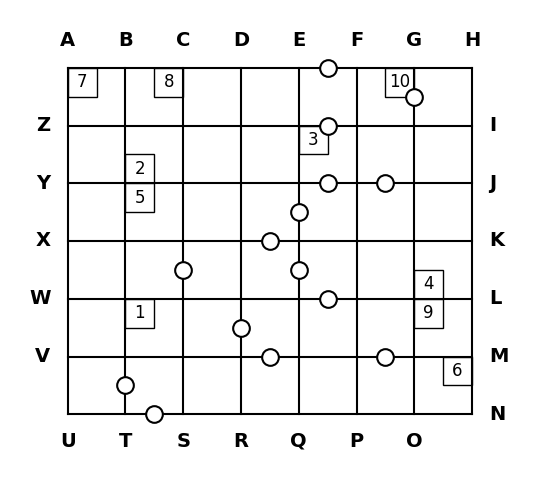

In [3]:
import matplotlib.pyplot as plt
import random
import string

def draw_grid_and_store_info(rows, cols, num_blocked_edges=20, num_buildings=10):
    fig, ax = plt.subplots(figsize=(cols, rows))
    point_info = {}

    # 初始化顶点信息
    for x in range(cols + 1):
        for y in range(rows + 1):
            point_info[(x, y)] = [
                1 if y < rows else 0,  # 上
                1 if y > 0 else 0,     # 下
                1 if x > 0 else 0,     # 左
                1 if x < cols else 0,  # 右
                [0, 0, 0, 0],          # 建筑信息[右上, 左上, 左下, 右下]
                ''                     # 字母标记（外围顶点）
            ]

    # 标记外围顶点（顺时针方向，从左上角开始）
    letters = list(string.ascii_uppercase)
    perimeter_points = []

    # 上边从左到右
    perimeter_points += [(x, rows) for x in range(cols + 1)]
    # 右边从上到下（不含第一个点）
    perimeter_points += [(cols, y) for y in range(rows - 1, -1, -1)]
    # 下边从右到左（不含第一个点）
    perimeter_points += [(x, 0) for x in range(cols - 1, -1, -1)]
    # 左边从下到上（不含第一个和最后一个点）
    perimeter_points += [(0, y) for y in range(1, rows)]

    # 字母标记稍微悬浮在外侧
    offset = 0.3
    for idx, (x, y) in enumerate(perimeter_points):
        letter = letters[idx % len(letters)]
        point_info[(x, y)][5] = letter

        # 根据位置确定字母偏移方向
        if y == rows:  # 上边
            ax.text(x, y + offset, letter, fontsize=14, color='black', ha='center', va='bottom', fontweight='bold')
        elif x == cols:  # 右边
            ax.text(x + offset, y, letter, fontsize=14, color='black', ha='left', va='center', fontweight='bold')
        elif y == 0:  # 下边
            ax.text(x, y - offset, letter, fontsize=14, color='black', ha='center', va='top', fontweight='bold')
        elif x == 0:  # 左边
            ax.text(x - offset, y, letter, fontsize=14, color='black', ha='right', va='center', fontweight='bold')

    # 所有可能的边
    edges = []
    for x in range(cols + 1):
        for y in range(rows + 1):
            if x < cols:
                edges.append(((x, y), (x + 1, y)))
            if y < rows:
                edges.append(((x, y), (x, y + 1)))

    # 随机阻塞边
    blocked_edges = random.sample(edges, min(num_blocked_edges, len(edges)))

    # 更新阻塞边信息
    for (start, end) in blocked_edges:
        x1, y1 = start
        x2, y2 = end
        if x1 == x2:  # 垂直边
            if y2 > y1:
                point_info[start][0] = 0
                point_info[end][1] = 0
            else:
                point_info[start][1] = 0
                point_info[end][0] = 0
        else:  # 水平边
            if x2 > x1:
                point_info[start][3] = 0
                point_info[end][2] = 0
            else:
                point_info[start][2] = 0
                point_info[end][3] = 0

    # 随机选择格子放置建筑
    all_cells = [(x, y) for x in range(cols) for y in range(rows)]
    building_cells = random.sample(all_cells, min(num_buildings, len(all_cells)))

    building_number = 1
    for (x, y) in building_cells:
        position = random.randint(1, 4)  # 1右上, 2左上, 3左下, 4右下
        half_size = 0.5
        if position == 1:  # 右上
            rect_x, rect_y = x + half_size, y + half_size
            point_info[(x + 1, y + 1)][4][2] = building_number
        elif position == 2:  # 左上
            rect_x, rect_y = x, y + half_size
            point_info[(x, y + 1)][4][3] = building_number
        elif position == 3:  # 左下
            rect_x, rect_y = x, y
            point_info[(x, y)][4][0] = building_number
        else:  # 右下
            rect_x, rect_y = x + half_size, y
            point_info[(x + 1, y)][4][1] = building_number

        building_rect = plt.Rectangle((rect_x, rect_y), half_size, half_size,
                                      facecolor='white', edgecolor='black')
        ax.add_patch(building_rect)

        ax.text(rect_x + half_size / 2, rect_y + half_size / 2, str(building_number),
                fontsize=12, ha='center', va='center')

        building_number += 1

    # 绘制网格线
    for x in range(cols + 1):
        ax.plot([x, x], [0, rows], color='black')
    for y in range(rows + 1):
        ax.plot([0, cols], [y, y], color='black')

    # 绘制阻塞边圆圈
    for (start, end) in blocked_edges:
        mid_x = (start[0] + end[0]) / 2
        mid_y = (start[1] + end[1]) / 2
        ax.plot(mid_x, mid_y, 'o', markersize=12, markerfacecolor='white',
                markeredgecolor='black', markeredgewidth=1.5)

    ax.set_xlim(-1, cols + 1)
    ax.set_ylim(-1, rows + 1)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

    return point_info

# 调用函数并输出结果
rows, cols = 6, 7
grid_info = draw_grid_and_store_info(rows, cols, num_blocked_edges=15, num_buildings=10)


In [2]:
import matplotlib.pyplot as plt
from collections import deque, defaultdict

# 根据字母找到对应的顶点坐标
def find_point_by_letter(grid_info, letter):
    for coord, info in grid_info.items():
        if info[5] == letter:
            return coord
    return None

# 普通 BFS 找到某一条最短路
def bfs_shortest_path(grid_info, start, end):
    queue = deque([start])
    visited = {start: None}
    directions = [(0,1),(0,-1),(-1,0),(1,0)]  # 上、下、左、右
    while queue:
        cur = queue.popleft()
        if cur == end:
            break
        edges = grid_info[cur][:4]
        for idx, (dx, dy) in enumerate(directions):
            if edges[idx] == 1:
                nb = (cur[0]+dx, cur[1]+dy)
                if nb in grid_info and nb not in visited:
                    visited[nb] = cur
                    queue.append(nb)
    # 回溯
    path = []
    if end in visited:
        cur = end
        while cur is not None:
            path.append(cur)
            cur = visited[cur]
        path.reverse()
    return path

# 计算每个顶点到终点的最短距离
def compute_distances_to_end(grid_info, end):
    dist = {end: 0}
    q = deque([end])
    directions = [(0,1),(0,-1),(-1,0),(1,0)]
    while q:
        cur = q.popleft()
        d = dist[cur]
        edges = grid_info[cur][:4]
        for idx,(dx,dy) in enumerate(directions):
            if edges[idx] == 1:
                nb = (cur[0]+dx, cur[1]+dy)
                if nb in grid_info and nb not in dist:
                    dist[nb] = d+1
                    q.append(nb)
    return dist

# 单步移动时“经过”的建筑
def get_crossed_buildings(prev, curr, grid_info):
    px,py = prev; cx,cy = curr
    binfo = grid_info[curr][4]
    crossed = set()
    dx,dy = cx-px, cy-py
    if dx == 1:      # 从左向右：检查左侧两块
        for idx in (1,2):
            if binfo[idx]: crossed.add(binfo[idx])
    elif dx == -1:   # 从右向左：检查右侧两块
        for idx in (0,3):
            if binfo[idx]: crossed.add(binfo[idx])
    elif dy == 1:    # 从下往上：检查下侧两块
        for idx in (2,3):
            if binfo[idx]: crossed.add(binfo[idx])
    elif dy == -1:   # 从上往下：检查上侧两块
        for idx in (1,0):
            if binfo[idx]: crossed.add(binfo[idx])
    return crossed

# 在所有最短路中找一条经过建筑最多的路径
def find_max_building_path(grid_info, start, end):
    # 1) 反向 BFS 得到 dist_to_end
    dist_to_end = compute_distances_to_end(grid_info, end)
    if start not in dist_to_end:
        return [], set()
    shortest_len = dist_to_end[start]

    # 2) 预取一条任意最短路，万一起最佳也没有过楼时可用
    any_path = bfs_shortest_path(grid_info, start, end)

    # 3) DFS 枚举所有最短路，记录过楼最多的
    directions = [(0,1),(0,-1),(-1,0),(1,0)]
    best_path = []
    best_buildings = set()
    best_count_at = defaultdict(int)  # 剪枝：(节点,步数)->最优过楼数

    def dfs(path, passed):
        nonlocal best_path, best_buildings
        cur = path[-1]
        step = len(path) - 1

        # 剪枝
        if best_count_at[(cur, step)] >= len(passed):
            return
        best_count_at[(cur, step)] = len(passed)

        if cur == end and step == shortest_len:
            if len(passed) > len(best_buildings):
                best_buildings = passed.copy()
                best_path = path.copy()
            return
        if step >= shortest_len:
            return

        for idx,(dx,dy) in enumerate(directions):
            nb = (cur[0]+dx, cur[1]+dy)
            if nb not in grid_info: continue
            # 必须通路
            if grid_info[cur][idx] == 0: continue
            # 必须继续走最短路上的下一个
            if dist_to_end.get(nb, 1e9) != dist_to_end[cur] - 1:
                continue
            new_bs = get_crossed_buildings(cur, nb, grid_info)
            dfs(path + [nb], passed | new_bs)

    dfs([start], set())

    # 4) 如果所有最短路都没经过任何楼，就返回任意一条最短路
    if not best_path:
        return any_path, set()
    return best_path, best_buildings

# 绘图函数（同前）
def draw_path(grid_info, path, rows, cols):
    fig, ax = plt.subplots(figsize=(cols, rows))
    # 网格
    for x in range(cols+1):
        ax.plot([x,x],[0,rows],color='black',linewidth=0.5)
    for y in range(rows+1):
        ax.plot([0,cols],[y,y],color='black',linewidth=0.5)
    # 阻塞边
    directions = [(0,1),(0,-1),(-1,0),(1,0)]
    for (x,y),info in grid_info.items():
        for idx,status in enumerate(info[:4]):
            if status==0:
                dx,dy = directions[idx]
                nb = (x+dx,y+dy)
                if nb in grid_info and (x,y)<nb:
                    mx,my = (x+nb[0])/2,(y+nb[1])/2
                    ax.plot(mx,my,'o',markersize=12,
                            markerfacecolor='white',
                            markeredgecolor='black',
                            markeredgewidth=1.5)
    # 建筑
    for (x,y),info in grid_info.items():
        half = 0.5
        offsets = [(0,0),(-half,0),(-half,-half),(0,-half)]
        for idx,bn in enumerate(info[4]):
            if bn:
                rx,ry = x+offsets[idx][0], y+offsets[idx][1]
                rect = plt.Rectangle((rx,ry),half,half,
                                     facecolor='lightgray',
                                     edgecolor='black')
                ax.add_patch(rect)
                ax.text(rx+half/2,ry+half/2,str(bn),
                        fontsize=12,ha='center',va='center')
    # 外围字母
    offset = 0.3
    for (x,y),info in grid_info.items():
        letter = info[5]
        if not letter: continue
        if y==rows:
            ax.text(x,y+offset,letter,ha='center',va='bottom',fontweight='bold')
        elif x==cols:
            ax.text(x+offset,y,letter,ha='left',va='center',fontweight='bold')
        elif y==0:
            ax.text(x,y-offset,letter,ha='center',va='top',fontweight='bold')
        elif x==0:
            ax.text(x-offset,y,letter,ha='right',va='center',fontweight='bold')
    # 路径
    if path:
        xs, ys = zip(*path)
        ax.plot(xs, ys, color='red', linewidth=3, marker='o', markersize=8)
    else:
        print("未找到路径！")
    ax.set_xlim(-1, cols+1)
    ax.set_ylim(-1, rows+1)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

# —— 主流程 ——
letter_start = 'A'
letter_end   = 'T'

start = find_point_by_letter(grid_info, letter_start)
end   = find_point_by_letter(grid_info, letter_end)
if start is None or end is None:
    print("未找到指定字母对应的顶点，请检查输入！")
else:
    path, buildings = find_max_building_path(grid_info, start, end)
    if len(buildings) == 0:
        # 所有最短路都未经过任何建筑
        print(0)
        # path 已经是任意一条最短路
        draw_path(grid_info, path, rows, cols)
    else:
        draw_path(grid_info, path, rows, cols)
        print("最短且经过建筑最多的路径长度：", len(path)-1)
        print("路径经过的建筑数：", len(buildings))
        print("路径经过的建筑编号：", buildings)


NameError: name 'grid_info' is not defined

In [4]:
for y in range(rows, -1, -1):
    for x in range(cols + 1):
        info = grid_info[(x, y)]
        print(f"顶点({x},{y}): 上:{info[0]} 下:{info[1]} 左:{info[2]} 右:{info[3]} 建筑[右上,左上,左下,右下]:{info[4]}")
    print("-" * 80)

顶点(0,6): 上:0 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 7]
顶点(1,6): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(2,6): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 8, 0]
顶点(3,6): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(4,6): 上:0 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(5,6): 上:0 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(6,6): 上:0 下:0 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 10, 0]
顶点(7,6): 上:0 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
--------------------------------------------------------------------------------
顶点(0,5): 上:1 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(1,5): 上:1 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(2,5): 上:1 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(3,5): 上:1 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(4,5): 上:1 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 3]
顶点(5,5): 上:1 下:1 左:0 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(6,5): 上:0 下:1 左:1 右:1 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
顶点(7,5): 上:1 下:1 左:1 右:0 建筑[右上,左上,左下,右下]:[0, 0, 0, 0]
------------------------------------------------------

In [5]:
for x in range(cols+1):
    for y in range(rows+1):
        info = grid_info[(x, y)]
        print(info[0], info[1], info[2], info[3], info[4][0], info[4][1],info[4][2],info[4][3])

1 0 0 1 0 0 0 0
1 1 0 1 0 0 0 0
1 1 0 1 0 0 0 0
1 1 0 1 0 0 0 0
1 1 0 1 0 0 0 0
1 1 0 1 0 0 0 0
0 1 0 1 0 0 0 7
0 0 1 0 0 0 0 0
1 0 1 1 0 0 0 0
1 1 1 1 0 0 0 1
1 1 1 1 0 0 0 0
1 1 1 1 2 0 0 5
1 1 1 1 0 0 0 0
0 1 1 1 0 0 0 0
1 0 0 1 0 0 0 0
1 1 1 1 0 0 0 0
0 1 1 1 0 0 0 0
1 0 1 1 0 0 0 0
1 1 1 1 0 0 0 0
1 1 1 1 0 0 0 0
0 1 1 1 0 0 8 0
1 0 1 1 0 0 0 0
0 1 1 0 0 0 0 0
1 0 1 1 0 0 0 0
1 1 1 0 0 0 0 0
1 1 1 1 0 0 0 0
1 1 1 1 0 0 0 0
0 1 1 1 0 0 0 0
1 0 1 1 0 0 0 0
1 1 0 1 0 0 0 0
0 1 1 0 0 0 0 0
0 0 0 1 0 0 0 0
1 0 1 0 0 0 0 0
1 1 1 0 0 0 0 3
0 1 1 0 0 0 0 0
1 0 1 1 0 0 0 0
1 1 1 0 0 0 0 0
1 1 0 1 0 0 0 0
1 1 1 1 0 0 0 0
1 1 0 0 0 0 0 0
1 1 0 1 0 0 0 0
0 1 0 1 0 0 0 0
1 0 1 1 0 0 0 0
1 1 0 1 0 0 0 0
1 1 1 1 4 0 0 9
1 1 1 1 0 0 0 0
1 1 0 1 0 0 0 0
0 1 1 1 0 0 0 0
0 0 1 1 0 0 10 0
1 0 1 0 0 0 0 0
1 1 1 0 0 0 6 0
1 1 1 0 0 0 0 0
1 1 1 0 0 0 0 0
1 1 1 0 0 0 0 0
1 1 1 0 0 0 0 0
0 1 1 0 0 0 0 0
